# Model Evaluation & Error Analysis

*Evaluation is how we decide whether a model is useful for a real decision, not merely whether it produces a high score.*

This notebook continues the housing example from supervised learning. The same rows and features support two different model tasks:

1. **Regression** predicts a number: a home's expected price.
2. **Classification** predicts the probability of a category: whether a home is above a price boundary.

Those outputs answer different questions, so they need different evaluation tools. A $100,000 price miss has a size; a classification mistake has a type, such as incorrectly flagging a standard home as premium. Neither family of metrics is universally better. The right choice depends on the output, the action someone will take, and the cost of each kind of error.

### What You Will Practice

- Build simple baselines that define what "useful" means.
- Validate model choices on data that was not used for fitting.
- Evaluate numeric predictions with regression metrics.
- Evaluate probability-based decisions with classification metrics and thresholds.
- Check whether probabilities mean what they claim to mean through calibration.
- Find systematic failures by examining errors within relevant market segments.

As you work, treat each metric and technique as a choice to defend. Ask: **What decision is this helping us make, and what could this measurement hide?**

----

## 1. Evaluating a Regression Model

### What are we predicting?

A regression model predicts a continuous number. Here, the target is `price`, so every prediction can be more or less wrong by a measurable amount.

### What question are we asking?

> How close are the predicted sale prices to the actual sale prices for homes the model has not seen before?

This question matters when the prediction itself informs a price estimate, budget, valuation, or planning decision. We need to know the size of the miss, not only whether the prediction falls on the correct side of a boundary.

### Why these metrics?

- **MAE** is the typical absolute price error. It is the primary metric because it is easy to translate into a conversation about dollars.
- **RMSE** gives extra weight to large misses. Use it alongside MAE when an occasional severe error is especially costly.
- **$R^2$** describes how much variation in price the model explains. It gives context, but does not tell us the size of an average mistake.

MAE is not mandatory. Choose RMSE as the primary metric when large price mistakes carry disproportionate risk. Use a percentile error measure when a typical average would hide an unacceptable tail of large errors.

### Setup

Reuse the preprocessing choices from the supervised-learning notebook. Split the data before fitting any transformation that learns from the data, and keep one test set untouched until the end.

### Why create a train/test split?

The linear regression model itself is the same model you used in the supervised-learning notebook. We still choose `area` as $X$, use `price` as $y$, fit `LinearRegression`, and predict prices.

The difference is **where we measure performance**.

If we train and evaluate on all the same rows:

```python
reg.fit(X, y)
y_pred = reg.predict(X)
```

we answer: **How closely does this fitted line describe the homes it has already seen?** That is useful for introducing linear regression and visualizing the line, but it is not evidence that the model will predict a new listing well.

This split creates two groups of homes:

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
```

- `X_train` and `y_train` contain 80% of the homes. The model uses these rows to learn the relationship between area and price.
- `X_test` and `y_test` contain the remaining 20%. The model does not see these prices while it is learning.
- `test_size=0.2` requests an 80/20 split.
- `random_state=42` makes the same random split every time you run the notebook, so your results are reproducible.

After fitting on the training rows, we predict the held-out feature values:

```python
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
```

Comparing `y_pred` with `y_test` now answers a more useful question: **For homes whose prices were hidden from the model, how far off are its predictions?**

The split does not change linear regression. It changes the claim you can make about it:

- **No split:** “This line describes these known examples.”
- **With a split:** “This model has this level of error on held-out examples, so it may be useful for future homes that resemble them.”

Later, $k$-fold cross-validation repeats this same idea across several different training/validation partitions. It gives a more stable estimate than relying on one random split, but the core principle is already here: do not judge a model only on examples it learned from.

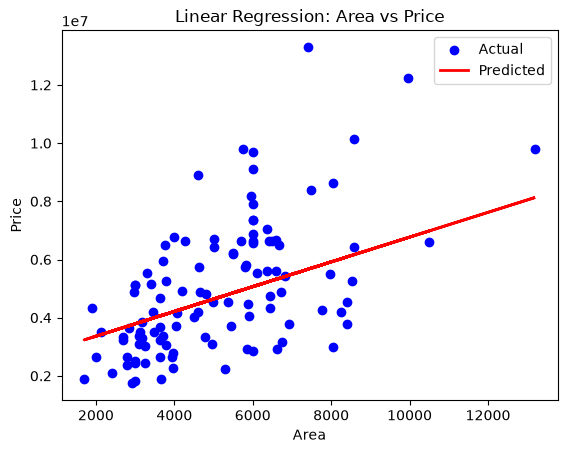

In [11]:
# TODO: Load the housing data, define features and the price target, and create train/test splits. 
# Once that is done, fit a linear regression model to the training data and evaluate its performance on the test data. 
# Visualize the results to better understand the relationship between the features and the target variable.

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from data_loader import load_housing_data


df = load_housing_data()

X = df[["area"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# next, we will fit a linear regression model to the training data and evaluate its performance on the test data. We will also visualize the results to better understand the relationship between the features and the target variable.
reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

plt.scatter(X_test, y_test, color="blue", label="Actual")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Predicted")
plt.title("Linear Regression: Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.legend()
plt.show()

## 2. Regression Baselines: "Better Than What?"

A baseline is a deliberately simple prediction rule. It gives a model score meaning. Without one, an MAE of $900,000 is just a number.

For this dataset, predict the **median training-set price** for every home. The median is a sensible starting point for MAE because it minimizes total absolute error among constant predictions. It establishes the question:

> Does the trained model use property features well enough to beat a single, no-information price estimate?

Next, compare a simple linear regression with a more flexible candidate model. This is not a rule that every project needs exactly these models. The point is to make complexity earn its place: prefer added complexity only when it gives a material, repeatable improvement or enables a capability the simpler model lacks.

Record MAE, RMSE, and $R^2$ for each candidate. Then ask: **Is the improvement large enough to matter for the price-estimation decision?**

In [ ]:
# TODO: Evaluate a median-price baseline and at least one regression model with MAE, RMSE, and R^2.

## 3. Regression Validation: "Will It Work Again?"

Training performance cannot answer this question: the model has already seen those examples. A held-out test set offers a more honest estimate, but one split can still be unusually easy or difficult.

Use $k$-fold cross-validation on the training data to compare models. It repeats the train/validation process across several partitions, so each training example is also used once for validation. Report the average validation MAE and how much it varies across folds.

> We are asking whether a model's improvement is stable across plausible samples of the available data, rather than a lucky result from one split.

This approach fits a small, non-temporal tabular dataset. It is not universal:

- Use chronological validation for forecasting because future data must never train a past prediction.
- Use grouped splits when rows from the same customer, home, or entity are related.
- Use a fixed holdout when it represents a meaningful future launch period.

Choose a finalist with cross-validation, then evaluate it on the untouched test set once. Repeatedly changing the model after looking at test performance turns the test set into training feedback.

In [ ]:
# TODO: Cross-validate the baseline and candidate models on training data, then select a model to evaluate once on test data.

## 4. Regression Error Analysis: "Who Does It Miss?"

An overall MAE is an average. A model can look reliable overall while being consistently worse for a useful kind of home.

Create a table with actual prices, predicted prices, residuals, and absolute errors. Then compare MAE across furnishing status, air conditioning, bedroom count, and price quartile.

> We are asking whether the model is equally useful across the market segments where its predictions might be used.

These slices are diagnostic tools, not an automatic reason to change the model. A worse slice may reveal missing features, limited examples, poor data quality, or a segment that needs a different decision policy. Inspect the largest individual errors as well: averages show a pattern; examples often explain it.

For this housing exercise, use property and market characteristics. In a real high-impact setting, subgroup analysis may also be necessary for fairness, safety, or regulatory reasons, with appropriate domain expertise and safeguards.

In [ ]:
# TODO: Build an error-analysis table, calculate slice-level MAE, and inspect the largest residuals.

## 5. Evaluating a Classification Model

### What are we predicting?

A classifier does not estimate a price. It estimates the probability that a home belongs to a class. Create the target `above_median_price`: `1` when the price is above the dataset median and `0` otherwise.

### What question are we asking?

> Can the model identify homes likely to be above the chosen price boundary, and what kinds of mistaken decisions will it make?

The outcome is now a category, so there is no meaningful "$100,000 too high" error. Instead, the important distinction is between false positives and false negatives.

### Why these metrics?

- **Accuracy** is the share of all correct decisions. It is a useful overview only when classes and mistake costs are reasonably balanced.
- **Precision** asks: among homes we flagged as above median, how often were we right?
- **Recall** asks: among homes that were actually above median, how many did we find?
- **F1** balances precision and recall when both error types matter similarly.
- **ROC-AUC** evaluates how well probabilities rank positive examples above negative ones across all thresholds.
- **Average precision** focuses on positive-class retrieval and is especially informative when positives are rare.

Begin with a `DummyClassifier`, then compare logistic regression and a tree-based model. The goal is not that this exact trio is required; it is to compare a no-signal benchmark, a simple probability model, and a flexible nonlinear model before choosing based on the decision.

In [ ]:
# TODO: Create the above-median target, train a dummy baseline and classifiers, then compare classification metrics.

## 6. Classification Thresholds: "What Action Should We Take?"

A classifier produces a probability, such as 0.62, but a workflow often needs a yes/no action. A **threshold** makes that conversion: flag a home when its predicted probability is at or above the threshold.

The familiar $0.50$ is a convention, not a requirement. It assumes that false positives and false negatives have similar costs. That is rarely a complete business argument.

Imagine a premium-sales team can review only a subset of listings:

- A **false positive** sends a standard home for unnecessary review.
- A **false negative** misses a genuinely premium home that could have benefited from review.

Compare thresholds such as $0.30$, $0.50$, and $0.70$ using a confusion matrix, precision, recall, and false-negative rate. Lower thresholds usually find more premium homes (higher recall) but create more unnecessary reviews (lower precision). Higher thresholds do the reverse.

> Choose the threshold that makes the tradeoff you can defend for this workflow, rather than choosing the threshold with the best-looking single metric.

Use a capacity constraint, an explicit cost estimate, or a target recall/precision level when one is available. The selected threshold should be evaluated on data not used to choose it.

In [ ]:
# TODO: Compare multiple probability thresholds and justify one using the chosen decision cost.

## 7. Calibration and Classification Error Slices

### Calibration: "Can We Trust the Probability?"

A model can rank homes well but attach unreliable probability values. Calibration tests the literal meaning of a prediction. If a group of homes receives predictions near 70%, roughly 70% of them should actually be above the median price.

Plot a calibration curve for each classifier. Then use `CalibratedClassifierCV` with the tree-based model and compare the result. Calibration is most important when the probability itself drives an action, such as triage, pricing, risk limits, or resource allocation. It is less important when only the ordering of cases matters.

### Classification Error Slices: "Where Does the Decision Break Down?"

Calculate precision, recall, and false-negative rate by furnishing status and bedroom-count groups. Overall performance can hide a segment where the chosen threshold misses too many premium homes or generates too many unnecessary reviews.

> We are asking whether the selected decision policy works consistently for the market segments it will serve.

Use the slices to form a hypothesis, not a verdict. A gap may call for more data, a better feature, a different threshold, or more careful investigation before changing the model.

In [ ]:
# TODO: Plot calibration curves, calibrate a classifier, and compare classification metrics by market segment.

## Final Recommendation: Make the Evaluation Defensible

End by writing a short recommendation, not merely listing scores. Answer these questions in your own words:

1. **Baseline:** What simple rule did the selected model beat, and was the improvement meaningful for the decision?
2. **Validation:** Why does your validation method represent the data this model will face next?
3. **Metrics:** Which metric is primary, what question does it answer, and what important behavior might it hide?
4. **Classification policy:** If you used a classifier, why does your threshold match the relative cost of its false positives and false negatives?
5. **Failures:** Which segments or examples expose the model's weakest performance, and what is the most plausible explanation?
6. **Next step:** What would you improve, collect, monitor, or verify before relying on the model more broadly?

A strong evaluation does not prove that a model is universally good. It makes a bounded claim: this model, measured this way, is useful for this decision under these assumptions.